In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Lasso, Ridge

In [89]:
df = pd.read_csv("C:/Users/Laptop Links/Desktop/python/Datasets/Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


In [91]:
df.shape

(375, 6)

In [92]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

<Axes: >

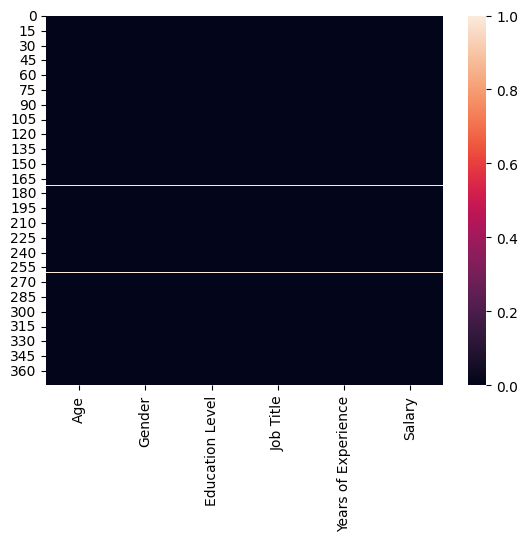

In [93]:
sns.heatmap(df.isnull())

In [94]:
df["Age"] = (df["Age"].fillna(df["Age"].mean()))
df["Years of Experience"] = (df["Years of Experience"].fillna(df["Years of Experience"].mean()))
df["Salary"] = (df["Salary"].fillna(df["Salary"].mean()))
df["Gender"] = (df["Gender"].fillna(df["Gender"].mode()[0]))
df["Education Level"] = (df["Education Level"].fillna(df["Education Level"].mode()[0]))
df["Job Title"] = (df["Job Title"].fillna(df["Job Title"].mode()[0]))

In [95]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

<Axes: title={'center': 'Gender distribution'}>

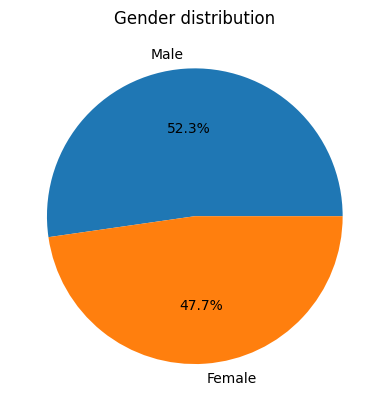

In [96]:
df["Gender"].value_counts().plot(kind="pie",autopct="%1.1f%%",title="Gender distribution")

In [97]:
df["Education Level"].unique()

<StringArray>
['Bachelor's', 'Master's', 'PhD']
Length: 3, dtype: str

<Axes: title={'center': 'Education Level distribution'}>

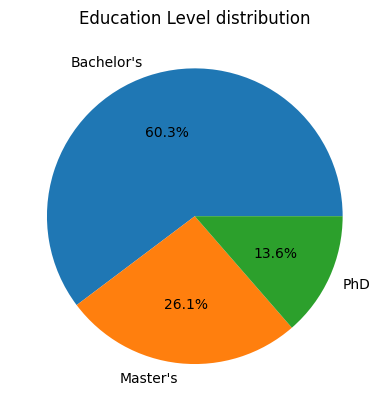

In [98]:
df["Education Level"].value_counts().plot(kind="pie",autopct="%1.1f%%",title="Education Level distribution")

In [99]:
df.duplicated().sum()

np.int64(50)

In [100]:
df = df.drop_duplicates()

In [101]:
df = df.reset_index()

In [102]:
df.tail()

,index,Age,Gender,Education Level,Job Title,Years of Experience,Salary
320,348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
321,349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
322,350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
323,351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0
324,371,43.0,Male,Master's,Director of Operations,19.0,170000.0


Text(0, 0.5, 'Age')

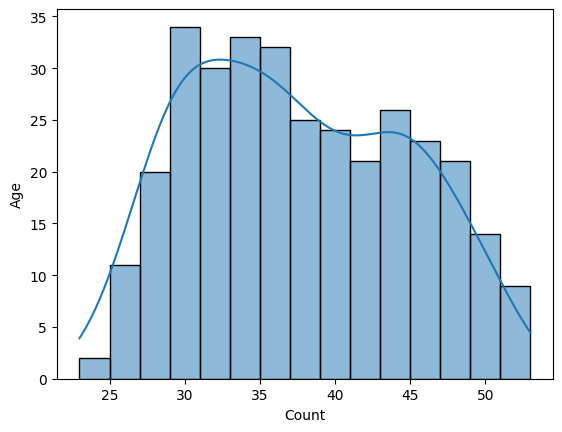

In [103]:
sns.histplot(df["Age"],kde=True,bins=15)
plt.xlabel("Count")
plt.ylabel("Age")

In [104]:
skewness = df['Age'].skew()
print("Skewness of Age:", skewness)
if skewness > 0:
    print("The Age distribution is positively skewed (tail on the right).")
elif skewness < 0:
    print("The Age distribution is negatively skewed (tail on the left).")
else:
    print("The Age distribution is approximately symmetric.")

Skewness of Age: 0.19543655092123433
The Age distribution is positively skewed (tail on the right).


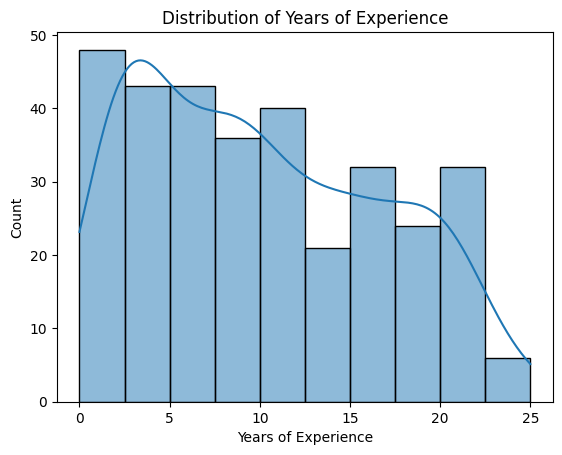

In [105]:
sns.histplot(df['Years of Experience'], kde=True, bins=10)
plt.title("Distribution of Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.show()
# It shows that many employees are entry-level or mid-experienced

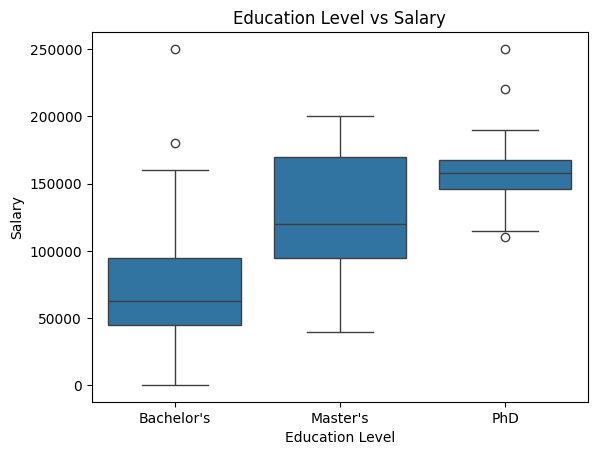

In [106]:
sns.boxplot(x="Education Level",y="Salary",data=df)
plt.title("Education Level vs Salary")
plt.show()
# Higher Education levels show high salary amount

In [107]:
avg_sal_gender = df.groupby("Gender")["Salary"].mean()
avg_sal_gender

Gender
Female     96136.363636
Male      103455.715473
Name: Salary, dtype: float64

In [108]:
high_avg = avg_sal_gender.idxmax()
print(high_avg,"earns more on average.")

Male earns more on average.


In [109]:
# Higher the education level then the average salary will also be higher.
# It means they are in direct relation.

Experience Category
0-5 years       49330.288462
6-10 years      92215.189873
11-15 years    114922.409576
16-20 years    158684.210526
20+ years      175400.000000
Name: Salary, dtype: float64


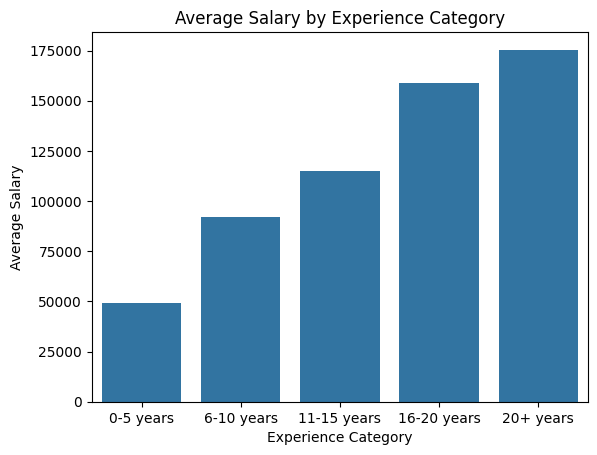

In [110]:
bins = [0, 5, 10, 15, 20, df['Years of Experience'].max()]
labels = ['0-5 years', '6-10 years', '11-15 years', '16-20 years', '20+ years']
df['Experience Category'] = pd.cut(df['Years of Experience'], bins=bins, labels=labels, right=True)

avg_salary_exp = df.groupby('Experience Category')['Salary'].mean()
print(avg_salary_exp)

sns.barplot(x=avg_salary_exp.index, y=avg_salary_exp.values)
plt.title("Average Salary by Experience Category")
plt.xlabel("Experience Category")
plt.ylabel("Average Salary")
plt.show()

In [111]:
df.columns

Index(['index', 'Age', 'Gender', 'Education Level', 'Job Title',
       'Years of Experience', 'Salary', 'Experience Category'],
      dtype='str')

In [112]:
df["Experience Category"] = (df["Experience Category"].fillna(df["Experience Category"].mode()[0]))

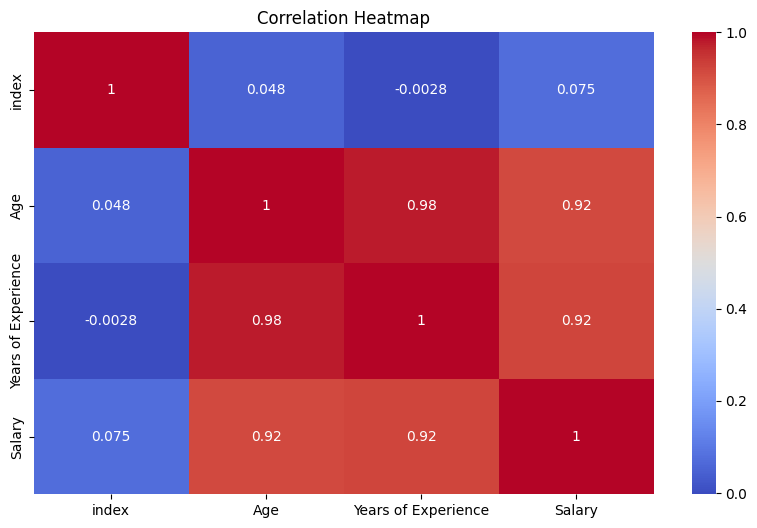

In [113]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [114]:
# Features with high correlation are strongly affecting the output.

In [115]:
X = df.drop('Salary', axis=1)
y = df['Salary']

In [116]:
# X (features): Age, Gender, Education Level, Years of Experience
# y (target): Salary

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
# To evaluate model performance on unseen data
# Prevents overfitting
# Ensures model generalization

In [119]:
X_train["Experience Category"]=(X_train["Experience Category"].fillna(X_train["Experience Category"].mode()[0]))
X_train.isnull().sum()

index                  0
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Experience Category    0
dtype: int64

In [120]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['Gender'] = le.fit_transform(X_train['Gender'])

In [121]:
X_train["Education Level"] = le.fit_transform(X_train["Education Level"])
X_train["Experience Category"] = le.fit_transform(X_train["Experience Category"])


In [125]:
X_train["Job Title"] = le.fit_transform(X_train["Job Title"])

In [126]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [127]:
# Algorithm: Linear Regression
# Suitable because:
# Predicts continuous values (Salary)
# Works well when relationships are linear
# Simple and interpretable

In [128]:
train_score = model.score(X_train, y_train)
print("Training Score:", train_score)

Training Score: 0.8935420355794811


In [129]:
# R² score on training data
# Value close to 1 → good fit

In [130]:
X_test["Experience Category"] = le.fit_transform(X_test["Experience Category"])
X_test['Gender'] = le.fit_transform(X_test['Gender'])
X_test['Education Level'] = le.fit_transform(X_test['Education Level'])
X_test['Job Title'] = le.fit_transform(X_test['Job Title'])

In [131]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9381631109265871


In [132]:
# R² shows how well model explains variance
# Example interpretation:
# 0.9 → excellent
# 0.7 → good
# <0.5 → weak

In [133]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 11881.296313252513


In [134]:
# Measures average prediction error
# Lower RMSE → better model
# Same unit as Salary

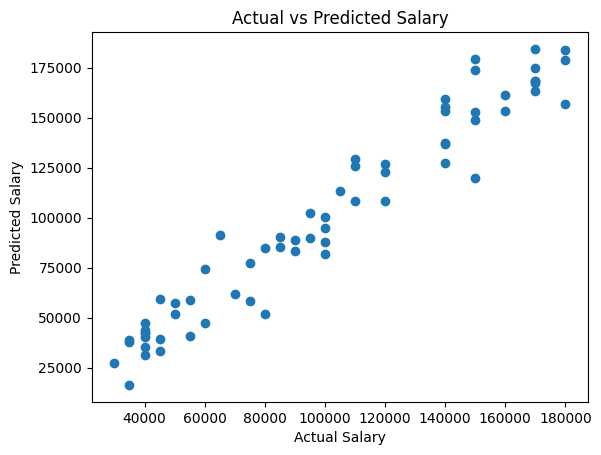

In [135]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [136]:
# Points close to diagonal line → good predictions
# Scattered points → errors
# Outliers indicate poor predictions

In [137]:
# Most important features

# Years of Experience → strongest predictor
# Education Level → affects salary levels
# Age → indirect effect
# Reason: higher correlation + logical real-world impact

In [138]:
# Important preprocessing steps

# Handling missing values (NaN)
# Removing duplicates
# Encoding categorical variables (Gender, Education)
# Feature scaling (if applied)
# Resetting index

In [ ]:
# How to improve model accuracy

# Feature Engineering

# Create new features

# Hyperparameter Tuning

# Optimize model parameters

# Try Advanced Models

# Random Forest
# Decision Tree
# Gradient Boosting

# Data Scaling

# Normalize/standardize features

# Remove Outliers

# Cross Validation